In [1]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

import xarray as xr



#######################
import bulk_model_code

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import intake 
cat = intake.open_catalog("https://gitlab.dkrz.de/data-infrastructure-services/era5-kerchunks/-/raw/main/main.yaml")

ds_sst = cat["surface_analysis_monthly"].to_dask()
sst = ds_sst.sst.sel(time="2020-02-01")

# sst_mask = xr.where((sst/sst).notnull(), 1.0, np.nan)
# sst_mask = sst_mask.compute().isel(time=0)

/work/mh1498/m301248/conda/envs/env_hacka/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [4]:
sst = sst.isel(time=0)
sst

<xarray.DataArray 'sst' (cell: 542080)> Size: 4MB
dask.array<getitem, shape=(542080,), dtype=float64, chunksize=(542080,), chunktype=numpy.ndarray>
Coordinates:
    lat      (cell) float64 4MB dask.array<chunksize=(542080,), meta=np.ndarray>
    lon      (cell) float64 4MB dask.array<chunksize=(542080,), meta=np.ndarray>
    time     datetime64[ns] 8B 2020-02-01T11:30:00
Dimensions without coordinates: cell
Attributes:
    typeOfLevel:                surface
    stepType:                   avg
    gridType:                   reduced_gg
    shortName:                  sst
    units:                      K
    name:                       Sea surface temperature
    cfVarName:                  sst
    gridDefinitionDescription:  Gaussian Latitude/Longitude Grid

### load land sea mask

In [5]:
ds_sst_mask = xr.open_dataset("/work/mh1498/m301248/TCO_data/QJRMS_0316/bulk_validation/E5_unstruct_landsea_invariant.nc")
land_mask = ds_sst_mask.var172.isel(time=0)
sst_mask  = 1. - land_mask

mask_mask = (sst_mask < 1.).compute()
sst_mask  = sst_mask.where(~mask_mask)
# mask_mask = (sst_mask == 1.).compute()
# sst_mask  = xr.where(sst_mask, 1., 0.)

sst_mask = sst_mask.rename({"rgrid":"cell"})

In [6]:
sst_mask

<xarray.DataArray 'var172' (cell: 542080)> Size: 2MB
array([ 1.,  1.,  1., ..., nan, nan, nan], shape=(542080,), dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2000-01-01T12:00:00
Dimensions without coordinates: cell
Attributes:
    table:                    128
    CDI_grid_type:            gaussian_reduced
    CDI_grid_num_LPE:         320
    CDI_grid_latitudes:       lat
    CDI_grid_reduced_points:  reduced_points

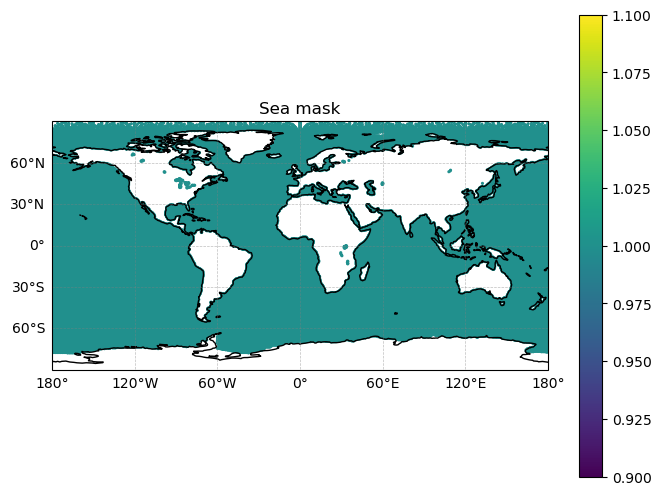

In [5]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_title("Sea mask")


# Add base features
ax.add_feature(cfeature.COASTLINE)

import matplotlib as mpl
# Lon, Lat = np.meshgrid(sst.lon.values, sst.lat.values)
norm = mpl.colors.Normalize(vmin=250, vmax=350)
sc = ax.scatter(sst.lon, sst.lat, c=sst_mask, s=1.5, transform=ccrs.PlateCarree()) #, norm=norm, cmap="veridis")
plt.colorbar(sc, ax=ax)

gl = ax.gridlines(draw_labels=True, 
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

# Turn on labels on bottom and left only
gl.top_labels = False
gl.right_labels = False

# Optionally format ticks (degrees + symbols)
gl.xformatter = cticker.LongitudeFormatter()
gl.yformatter = cticker.LatitudeFormatter()

#### load atmospheric data

In [7]:
era5 = cat["pressure-level_analysis_monthly"].to_dask()
era5_feb = era5.sel(time="2020-02-01").squeeze()
era5_feb

/work/mh1498/m301248/conda/envs/env_hacka/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 3GB
Dimensions:  (level: 37, cell: 542080)
Coordinates:
  * level    (level) int64 296B 1 2 3 5 7 10 20 ... 850 875 900 925 950 975 1000
    lat      (cell) float64 4MB dask.array<chunksize=(542080,), meta=np.ndarray>
    lon      (cell) float64 4MB dask.array<chunksize=(542080,), meta=np.ndarray>
    time     datetime64[ns] 8B 2020-02-01T11:30:00
Dimensions without coordinates: cell
Data variables: (12/16)
    cc       (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
    ciwc     (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
    clwc     (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
    crwc     (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
    cswc     (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
    d        (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
    ...       ...
    t        (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
    u        (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
    v        (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
    vo       (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
    w        (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
    z        (level, cell) float64 160MB dask.array<chunksize=(5, 542080), meta=np.ndarray>
Attributes: (12/22)
    project:              ECMWF Re-Analysis
    project_id:           ERA
    institution_id:       ECMWF-DKRZ
    institution:          Data from European Centre for Medium-Range Weather ...
    source_id:            IFS
    source:               ECMWF Integrated Forecast System (IFS) CY41R2
    ...                   ...
    format:               kerchunk
    product:              reanalysis
    responsible_persons:  Angelika Heil, Fabian Wachsmann
    title:                The DKRZ ERA5 data pool. Generated using Copernicus...
    license:              The ERA5 data are published with the Copernicus Pro...
    references:           Hersbach, H., Bell, B., Berrisford, P., Hirahara, S...

In [ ]:
# # - staggered mid-levels
# level_mid = 0.5 * (era5_feb.d.level + era5_feb.d.level.shift(level=-1)).isel(level=slice(None, -1))
# level_mid = level_mid.rename({"level": "level_mid"})

# # - staggered divergence
# stagg_div = 0.5 * (era5_feb.d + era5_feb.d.shift(level=-1))
# stagg_div = stagg_div.isel(level=slice(None, -1))
# stagg_div = stagg_div.rename({"level": "level_mid"}).assign_coords(level_mid=level_mid)

# # - vertical layer thickness in Pa or meters
# dp = - era5_feb.d.level.diff("level")  # length matches stagg_div
# stagg_div = stagg_div.transpose("time", "cell", "level_mid")
# dw = stagg_div * (100) * dp.data
# stagg_div = stagg_div.transpose("time", "level_mid", "cell")

# # - vertical integration from surface w0
# w0 = (era5_feb.w.sel(level=1000) + era5_feb.w.sel(level=975))*0.5
# w = w0 + dw.cumsum(dim="level_mid")
# w = w.transpose("time", "level_mid", "cell")

In [8]:
#  Extract level and compute thickness
levels = era5_feb.level
thickness = levels.diff('level')  # Layer thickness (e.g., in hPa)

# Mask to keep only levels between 650 and 750
mask = (levels >= 550) & (levels <= 850)
thickness = thickness.where(mask, drop=True)


# Compute weighted average over level
weighted_avg_w = (
    (era5_feb.w * thickness).sum(dim='level') 
    / thickness.sum(dim='level')
)
weighted_avg_D = (
    (era5_feb.d * thickness).sum(dim='level') 
    / thickness.sum(dim='level')
)

# Now weighted_avg is a Dask array with dims (time, cell)
# You can compute it later if needed:
# weighted_avg = weighted_avg.compute()

mask_subsidence = xr.where((weighted_avg_w > 0.)&((weighted_avg_D > 0.)), 1.0, np.nan).compute()   #(weighted_avg > 0.).compute().isel(time=0)

# cell_indices = np.where(sst_mask)[0]
# mask_subsidence = mask_subsidence.isel(cell=cell_indices)



In [54]:
# # Extract the cell coordinates
# cell_lons = mask_subsidence.lon  # shape (cell,)
# cell_lats = mask_subsidence.lat  # shape (cell,)

# # Interpolate sst_mask onto the cell points
# sst_mask_on_cells = sst_mask.sel(
#     lat=cell_lats,
#     lon=cell_lons,
#     method="nearest"
# )
# # Result has dimensions (time, cell) — matches mask_subsidence

# # Now apply the mask
# mask_subsidence_masked = mask_subsidence.where(sst_mask_on_cells == 1.)
# mask_subsidence_masked

In [9]:
lon_mask = xr.where((era5_feb.lon > 0.)
                         &(era5_feb.lon < 20.)
                         |(era5_feb.lon > 200.), 1.0, np.nan)
lat_mask = xr.where(((era5_feb.lat > -45.)
                    &(era5_feb.lat < 45.)), 1., np.nan)

tropical_mask = (lon_mask*lat_mask).compute()

In [10]:
total_mask = (sst_mask) * (mask_subsidence) * (tropical_mask)

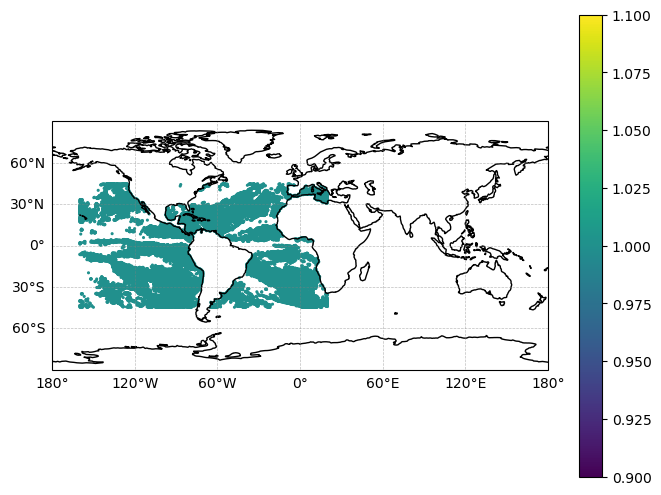

In [9]:

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add base features
ax.add_feature(cfeature.COASTLINE)
# ax.set_extent([vol_lon[0] - 1.5, vol_lon[1] + 1.5, vol_lat[0] - 1.5, vol_lat[1] + 1.5], crs=ccrs.PlateCarree())

# # Draw the rectangle (as a closed polygon)
# lons = [vol_lon[0], vol_lon[1], vol_lon[1], vol_lon[0], vol_lon[0]]
# lats = [vol_lat[0], vol_lat[0], vol_lat[1], vol_lat[1], vol_lat[0]]
# ax.plot(lons, lats, color='red', linewidth=2, transform=ccrs.PlateCarree())


sc = ax.scatter(era5_feb.lon, era5_feb.lat, c=total_mask, s=1.5)
plt.colorbar(sc, ax=ax)



# era5_sst.isel(time=0).plot.contourf(
#     ax=ax,
#     transform=ccrs.PlateCarree(),
#     cmap="viridis",
#     levels=20,
#     robust=True,
#     cbar_kwargs={'label': 'SST (°C)'}
# )

# ax.text(BCO_lon, BCO_lat, "BCO")

gl = ax.gridlines(draw_labels=True, 
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

# Turn on labels on bottom and left only
gl.top_labels = False
gl.right_labels = False

# Optionally format ticks (degrees + symbols)
gl.xformatter = cticker.LongitudeFormatter()
gl.yformatter = cticker.LatitudeFormatter()

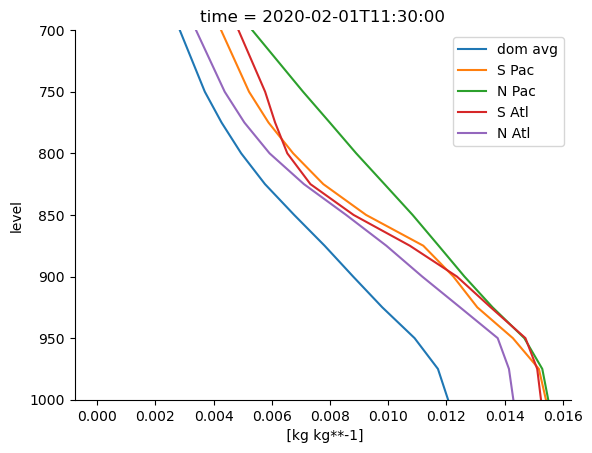

In [58]:
Spacific_mask = xr.where((era5_feb.lat > -10.)
                         &(era5_feb.lat < 0.)
                         &(era5_feb.lon > 240.)
                         &(era5_feb.lon < 250.), 1.0, np.nan).compute()

Npacific_mask = xr.where((era5_feb.lat > 5.)
                         &(era5_feb.lat < 15.)
                         &(era5_feb.lon > 200.)
                         &(era5_feb.lon < 210.), 1.0, np.nan).compute()

Satlantic_mask = xr.where((era5_feb.lat > -15.)
                         &(era5_feb.lat < -5.)
                         &(era5_feb.lon > 340.)
                         &(era5_feb.lon < 350.), 1.0, np.nan).compute()

Natlantic_mask = xr.where((era5_feb.lat > 5.)
                         &(era5_feb.lat < 15.)
                         &(era5_feb.lon > 300.)
                         &(era5_feb.lon < 310.), 1.0, np.nan).compute()


(era5_feb.q*total_mask).mean(dim="cell").plot.line(y="level", label="dom avg")
(era5_feb.q*Spacific_mask).mean(dim="cell").plot.line(y="level", label="S Pac")
(era5_feb.q*Npacific_mask).mean(dim="cell").plot.line(y="level", label="N Pac")
(era5_feb.q*Satlantic_mask).mean(dim="cell").plot.line(y="level", label="S Atl")
(era5_feb.q*Natlantic_mask).mean(dim="cell").plot.line(y="level", label="N Atl")

plt.gca().invert_yaxis()
plt.ylim(1000,700)
plt.legend()


for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)

#### collect data to run bulk model

In [11]:
entrainment_level = 800. # hPa
ref_p = 1000.            # hPa

cpd  = 1004.67           # J/K/kg
Rd = 287.1
frac_Ustar = 0.9

Omega = 2*np.pi/86400 # [rad/s] Earth rotation.
latitude0 = 10 # degree N
f = Omega * np.sin(latitude0*np.pi/180)


sst     = (ds_sst.sst.sel(time="2020-02-01").squeeze())
sst     = sst.where((sst >= 273) & (sst <= 315))*total_mask

## these will be needed to select unstructured lats and lons
nan_indices = sst.isnull().compute()

q_free  = era5_feb.q.sel(level=entrainment_level)*total_mask
th_free = ((era5_feb.t.sel(level=entrainment_level))*((ref_p/entrainment_level)**(0.286)))*total_mask
D       = weighted_avg_D*total_mask
U_free  = era5_feb.u.sel(level=entrainment_level)*total_mask
V_free  = era5_feb.v.sel(level=entrainment_level)*total_mask

ps      = (ds_sst.sp.sel(time="2020-02-01").squeeze())
ps      = (ps/100.)   #.fillna(1000.)/100.  # hPa


th_s = (sst*(ref_p/ps)**(Rd/cpd)) 
q_s = (bulk_model_code.qsea(sst-273.15,ps)*1e-3)

ps = ps*total_mask




# initial conditions vector  
y0 = [500*xr.ones_like(sst).dropna(dim="cell"),                      #.fillna(0.),
    (q_s - q_free).dropna(dim="cell"),                       #.fillna(0.),
    (th_s-2.).dropna(dim="cell")  ,                     #.fillna(0.), 
    (U_free - 3.).dropna(dim="cell") ,                      #.fillna(0.), 
    (V_free -1.).dropna(dim="cell")]                      #.fillna(0.)]) 


## to use later for plotting
lat_sel, lon_sel = era5_feb.lat.compute().where(~nan_indices, drop=True), era5_feb.lon.compute().where(~nan_indices, drop=True)
cells_sel = era5_feb.cell.compute().where(~nan_indices, drop=True)

max_t = 1e5
dt_max = 60
time = [0, max_t]


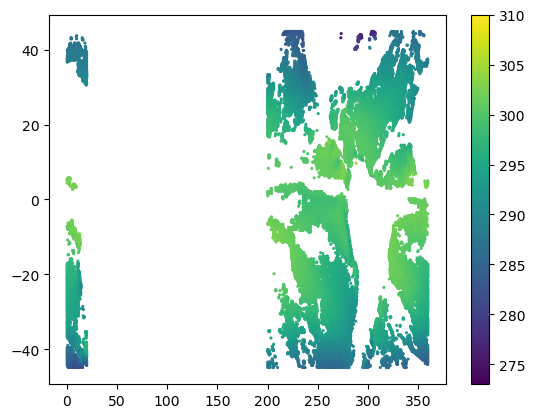

In [27]:
sc = plt.scatter(lon_sel, lat_sel, c=sst.dropna(dim="cell"), s=1.5, vmin=273, vmax=310)
plt.colorbar(sc)

In [ ]:
'''## takes too long to plot

fig, ax = plt.subplots(2, 3, figsize=(12, 8), 
                          subplot_kw={'projection': ccrs.PlateCarree()})


sc = ax[0,0].scatter(era5_feb.lon, era5_feb.lat, c=sst, s=1.5, vmin=273, vmax=310)
plt.colorbar(sc, ax=ax[0,0])

sc = ax[0,1].scatter(era5_feb.lon, era5_feb.lat, c=th_s, s=1.5, vmin=290, vmax=310)
plt.colorbar(sc, ax=ax[0,1])

sc = ax[0,2].scatter(era5_feb.lon, era5_feb.lat, c=q_s*1e3, s=1.5, vmin=15, vmax=25)
plt.colorbar(sc, ax=ax[0,2])

sc = ax[1,0].scatter(era5_feb.lon, era5_feb.lat, c=D, s=1.5, vmin=-10e-6, vmax=10e-6)
plt.colorbar(sc, ax=ax[1,0])

sc = ax[1,1].scatter(era5_feb.lon, era5_feb.lat, c=th_free, s=1.5, vmin=300, vmax=320)
plt.colorbar(sc, ax=ax[1,1])

sc = ax[1,2].scatter(era5_feb.lon, era5_feb.lat, c=q_free*1e3, s=1.5, vmin=4, vmax=10)
plt.colorbar(sc, ax=ax[1,2])




for x in ax.flatten():
    x.add_feature(cfeature.COASTLINE)

    gl = x.gridlines(draw_labels=True, 
                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # Turn on labels on bottom and left only
    gl.top_labels = False
    gl.right_labels = False

    # Optionally format ticks (degrees + symbols)
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()'''

# implement control command in bulk model 
def ... :
   if sst == 0.:
       no 

In [12]:
import numpy as np
from scipy.integrate import solve_ivp
import warnings

# def idx(x, i):
#     """Index into x[i] only if x is an array, otherwise return scalar."""
#     return x[i] if x.ndim > 0 else x.item()

# n_vars, n_cells = y0.shape

def to_np(x):
    return x.values if hasattr(x, "values") else np.asarray(x)

# sst_np        = to_np(sst)
# D_np          = to_np(D)
# q_free_np     = to_np(q_free)
# th_free_np    = to_np(th_free)
# ps_np         = to_np(ps)
# f_np          = to_np(f)
# U_free_np     = to_np(U_free)
# V_free_np     = to_np(V_free)
# frac_Ustar_np = to_np(frac_Ustar)
# y0_np         = to_np(y0)

sst_clean = sst.dropna(dim="cell")
q_free_clean = q_free.dropna(dim="cell")
th_free_clean = th_free.dropna(dim="cell")
D_clean = D.dropna(dim="cell")
U_free_clean = U_free.dropna(dim="cell")
V_free_clean = V_free.dropna(dim="cell")
ps_clean = ps.dropna(dim="cell")

In [44]:
i = int(10000.)

print(f"lat, lon = {lat_sel[i].values}, {lon_sel[i].values}")

y0_local = [y0[0][i].values.item(), y0[1][i].values.item(), y0[2][i].values.item(), y0[3][i].values.item(), y0[4][i].values.item()]
print(y0_local)

sol = solve_ivp(
        bulk_model_code.bulk_ERA5,
        time,
        y0_local,
        dense_output=True,
        max_step=dt_max,
        args=(
            sst_clean[i].values, D_clean[i].values, q_free_clean[i].values, th_free_clean[i].values, ps_clean[i].values, f,
            U_free_clean[i].values, V_free_clean[i].values, frac_Ustar,
        ),
    )

sol

lat, lon = 24.309125603539318, 293.1
[500.0, 0.01529465925359125, 294.3133412830318, -3.5015316009521484, 0.3563518524169922]
integration timestep 0.0


  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.560e-01 ...  9.995e+04  1.000e+05]
        y: [[ 5.000e+02  4.997e+02 ...  3.028e+02  3.028e+02]
            [ 1.529e-02  1.529e-02 ...  1.442e-02  1.442e-02]
            ...
            [-3.502e+00 -3.501e+00 ... -7.530e-01 -7.528e-01]
            [ 3.564e-01  3.564e-01 ...  1.206e+00  1.206e+00]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7ffad2f252e0>
 t_events: None
 y_events: None
     nfev: 10016
     njev: 0
      nlu: 0

In [50]:
solutions = []


# class IntegrationDiverged(Exception):
#     pass
converged_mask = np.ones(cells_sel.values.size, dtype=bool)

for i in range(cells_sel.values.size):

    if i < 10:
        print(i)

    if i == ( (cells_sel.values.size)//2 ):
        print("half way!")

    try:
        sol = solve_ivp(
            bulk_model_code.bulk_ERA5,
            time,
            [y0[0][i].values.item(), y0[1][i].values.item(), y0[2][i].values.item(), y0[3][i].values.item(), y0[4][i].values.item()],
            dense_output=True,
            max_step=dt_max,
            args=(
                sst_clean[i].values, D_clean[i].values, q_free_clean[i].values, th_free_clean[i].values,
                ps_clean[i].values, f, U_free_clean[i].values, V_free_clean[i].values, frac_Ustar,
            ),
        )
        solutions.append(sol)

    except bulk_model_code.IntegrationDiverged as e:
        print(f"Point {i} diverged — skipping. Reason: {e}")
        converged_mask[i] = False
        solutions.append(None)   # keep indexing consistent

0
integration timestep 0.0
Point 0 diverged — skipping. Reason: RuntimeWarning at t=65976.79: invalid value encountered in sqrt
1
integration timestep 0.0
Point 1 diverged — skipping. Reason: RuntimeWarning at t=66869.93: invalid value encountered in sqrt
2
integration timestep 0.0
Point 2 diverged — skipping. Reason: RuntimeWarning at t=67358.04: invalid value encountered in sqrt
3
integration timestep 0.0
Point 3 diverged — skipping. Reason: RuntimeWarning at t=67799.20: invalid value encountered in sqrt
4
integration timestep 0.0
Point 4 diverged — skipping. Reason: RuntimeWarning at t=68252.91: invalid value encountered in sqrt
5
integration timestep 0.0
Point 5 diverged — skipping. Reason: RuntimeWarning at t=69017.23: invalid value encountered in sqrt
6
integration timestep 0.0
Point 6 diverged — skipping. Reason: RuntimeWarning at t=71266.49: invalid value encountered in sqrt
7
integration timestep 0.0
Point 7 diverged — skipping. Reason: RuntimeWarning at t=73835.85: invalid va

KeyboardInterrupt: 

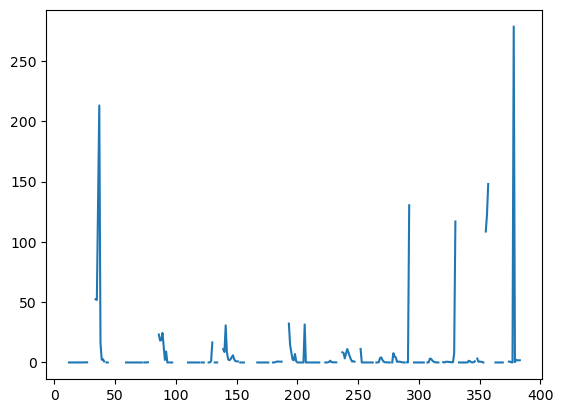

In [59]:
h = []
for s in solutions:
    if s is None:
        h.append(np.nan)
    else:
        h.append(s.y[0][-1])


h = np.asarray(h)
plt.plot(h)

### new solution to speed things up

In [14]:
import os

# Respect the CPUs allocated to your job by the scheduler (SLURM/PBS)
n_workers = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count()))
print(f"Using {n_workers} workers")

Using 256 workers


In [15]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from bulk_model_code import solve_single_point, IntegrationDiverged
import numpy as np

n_points = cells_sel.values.size

# Pre-extract all scalars ONCE outside the loop
args_list = [
    (
        i,
        [y0[0][i].values.item(), y0[1][i].values.item(), y0[2][i].values.item(),
         y0[3][i].values.item(), y0[4][i].values.item()],
        sst[i].values.item(),
        D[i].values.item(),
        q_free[i].values.item(),
        th_free[i].values.item(),
        ps[i].values.item(),
        f,
        U_free[i].values.item(),
        V_free[i].values.item(),
        frac_Ustar,
        time,
        dt_max,
    )
    for i in range(n_points)
]

# Run in parallel
solutions = [None] * n_points
converged_mask = np.ones(n_points, dtype=bool)


import os

# Respect the CPUs allocated to your job by the scheduler (SLURM/PBS)
n_workers = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count()))
print(f"Using {n_workers} workers")

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    futures = {executor.submit(solve_single_point, args): args[0] for args in args_list}
    
    completed = 0
    for future in as_completed(futures):
        i, sol = future.result()
        solutions[i] = sol
        if sol is None:
            converged_mask[i] = False
        completed += 1
        if completed % (n_points // 10) == 0:
            print(f"Progress: {completed}/{n_points}")

KeyboardInterrupt: 

## old stuff

In [45]:
import numpy as np
from scipy.integrate import solve_ivp
import warnings

def idx(x, i):
    """Index into x[i] only if x is an array, otherwise return scalar."""
    return x[i] if x.ndim > 0 else x.item()

n_vars, n_cells = y0.shape

def to_np(x):
    return x.values if hasattr(x, "values") else np.asarray(x)

sst_np        = to_np(sst)
D_np          = to_np(D)
q_free_np     = to_np(q_free)
th_free_np    = to_np(th_free)
ps_np         = to_np(ps)
f_np          = to_np(f)
U_free_np     = to_np(U_free)
V_free_np     = to_np(V_free)
frac_Ustar_np = to_np(frac_Ustar)
y0_np         = to_np(y0)

# --- Failure tracking (mutable, so the closure can write to it) ---
active       = np.ones(n_cells, dtype=bool)   # True  = still integrating
failed_at_t  = np.full(n_cells, np.nan)        # time of first failure per cell
failure_log  = []                              # (t, cell_idx, exception_str)

def vec_func_flat(t, y_flat, sst, D, q_free, th_free, ps, f,
                  U_free, V_free, frac_Ustar):

    Y    = y_flat.reshape(n_vars, n_cells)
    dYdt = np.zeros_like(Y)          # zeros → frozen cells stay frozen

    for i in range(n_cells):
        if (i/n_cells == 0.5):
            print("half domain!")

        if not active[i]:            # already failed — keep derivative = 0
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("error", RuntimeWarning)
                dYdt[:, i] = bulk_model_code.bulk_ERA5(
                    t,
                    Y[:, i],
                    idx(sst, i), idx(D, i), idx(q_free, i), idx(th_free, i),
                    idx(ps, i), idx(f, i), idx(U_free, i), idx(V_free, i),
                    idx(frac_Ustar, i),
                )

        except (RuntimeWarning, Exception) as e:
            active[i]      = False
            failed_at_t[i] = t
            failure_log.append((t, i, str(e)))
            # dYdt[:, i] already 0 — cell is now frozen
            # print(f"[t={t:.4f}] cell {i} deactivated: {e}")

    return dYdt.ravel()

# --- Single solve_ivp call (identical to before) ---
sol = solve_ivp(
    vec_func_flat,
    (time[0], time[-1]),
    y0_np.ravel(),
    dense_output=True,
    max_step=dt_max,
    args=(
        sst_np, D_np, q_free_np, th_free_np, ps_np, f_np,
        U_free_np, V_free_np, frac_Ustar_np,
    ),
)

# --- Unpack results (unchanged) ---
Y_out   = sol.y.reshape(n_vars, n_cells, -1)
t_eval  = np.linspace(time[0], time[-1], 500)
Y_dense = sol.sol(t_eval).reshape(n_vars, n_cells, -1)

# --- Post-integration failure report ---
n_failed = (~active).sum()
print(f"\n{n_failed}/{n_cells} cells failed during integration.")
if n_failed:
    print("Failed cells and times:")
    for t_f, i_f, msg in failure_log:
        print(f"  cell {i_f:>5d}  t={t_f:.4f}  reason: {msg}")

# --- Mask failed cells in output (optional but recommended) ---
Y_out[  :, ~active, :] = np.nan
Y_dense[:, ~active, :] = np.nan

t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0

KeyboardInterrupt: 

In [ ]:
# import numpy as np
# from scipy.integrate import solve_ivp



# def idx(x, i):
#     """Index into x[i] only if x is an array, otherwise return scalar."""
#     return x[i] if x.ndim > 0 else x.item()



# n_vars, n_cells = y0.shape  # e.g. (5, 1000)

# # --- Convert xarray args to numpy once, outside the solver ---
# def to_np(x):
#     return x.values if hasattr(x, "values") else np.asarray(x)

# sst_np        = to_np(sst)
# D_np          = to_np(D)
# q_free_np     = to_np(q_free)
# th_free_np    = to_np(th_free)
# ps_np         = to_np(ps)
# f_np          = to_np(f)
# U_free_np     = to_np(U_free)
# V_free_np     = to_np(V_free)
# frac_Ustar_np = to_np(frac_Ustar)
# y0_np         = to_np(y0)   # shape (n_vars, n_cells)

# # --- Wrapper: loops over cells, passes full state vector y[:,i] to scalar func ---
# def vec_func_flat(t, y_flat, sst, D, q_free, th_free, ps, f,
#                   U_free, V_free, frac_Ustar):

#     Y = y_flat.reshape(n_vars, n_cells)   # (n_vars, n_cells)
#     dYdt = np.empty_like(Y)

#     for i in range(n_cells):
#         dYdt[:, i] = bulk_model_code.bulk_ERA5(
#             t,
#             Y[:, i],
#             idx(sst, i), idx(D, i), idx(q_free, i), idx(th_free, i), idx(ps, i),
#             idx(f, i), idx(U_free, i), idx(V_free, i), idx(frac_Ustar, i),
#         )

#     return dYdt.ravel()

# # --- Single solve_ivp call ---
# sol = solve_ivp(
#     vec_func_flat,
#     (time[0], time[-1]),              # (t_start, t_end) as a 2-tuple
#     y0_np.ravel(),                    # flatten (n_vars, n_cells) → 1D
#     dense_output=True,
#     max_step=dt_max,
#     args=(
#         sst_np, D_np, q_free_np, th_free_np, ps_np, f_np,
#         U_free_np, V_free_np, frac_Ustar_np,
#     ),
# )

# # --- Unpack results ---
# # sol.y has shape (n_vars*n_cells, n_timepoints)
# Y_out = sol.y.reshape(n_vars, n_cells, -1)   # → (n_vars, n_cells, n_timepoints)

# # If you need the dense solution evaluated at specific times:
# t_eval = np.linspace(time[0], time[-1], 500)
# Y_dense = sol.sol(t_eval).reshape(n_vars, n_cells, -1)

q_flux_s: 9.731788867337977e-05
q_s - y[1]: 0.0107056577980984
delta_q: 1.906512858754969e-05
w_star: 0.4915985880700841
th_s - y[2]: 2.0


UnboundLocalError: cannot access local variable 'sigma_q' where it is not associated with a value

In [ ]:
# import numpy as np
# from scipy.integrate import solve_ivp

# n_vars, n_cells = y0.shape  # e.g. (5, 1000)
# vec_func = np.vectorize(bulk_model_code.neggers_et_al_2006_stevens_et_al_2002_fracUstar)
# # neggers_et_al_2006_stevens_et_al_2002_fracUstar takes the following arguments
# # t,y,SST,D,q_free,th_free,ps,f,U_free,V_free, frac_Ustar

# # --- Wrapper that flattens/unflattens around your existing vec_func ---
# def vec_func_flat(t, y_flat, sst, D, q_free, th_free, ps, f,
#                   U_free, V_free, frac_Ustar):

#     Y = y_flat.reshape(n_vars, n_cells)          # 1D → 2D for vec_func

#     dYdt = vec_func(t, Y, sst, D,      # your original function,
#                     q_free, th_free, ps, f,        # unchanged
#                     U_free, V_free, frac_Ustar)

#     return dYdt.ravel()                            # 2D → 1D for solve_ivp


# # --- Convert xarray args to numpy once, outside the solver ---
# def to_np(x):
#     return x.values if hasattr(x, "values") else np.asarray(x)

# args_np = (to_np(sst), to_np(D),
#     to_np(q_free), to_np(th_free), to_np(ps), to_np(f),
#     to_np(U_free), to_np(V_free), to_np(frac_Ustar),
# )

# # --- Single solve_ivp call ---
# sol = solve_ivp(
#     vec_func_flat,
#     (time[0], time[-1]),          # (t_start, t_end) as a 2-tuple
#     y0.ravel(),            # flatten (n_vars, n_cells) → 1D
#     dense_output=True,
#     max_step=dt_max,
#     args=args_np,
# )

# # --- Unpack results ---
# # sol.y has shape (n_vars*n_cells, n_timepoints)
# Y_out = sol.y.reshape(n_vars, n_cells, -1)   # → (n_vars, n_cells, n_timepoints)

# # If you need the dense solution evaluated at specific times:
# t_eval = np.linspace(time[0], time[-1], 500)
# Y_dense = sol.sol(t_eval).reshape(n_vars, n_cells, -1)

IndexError: invalid index to scalar variable.

In [ ]:
# from scipy.integrate import solve_ivp

# f = f*total_mask
# frac_Ustar = frac_Ustar*total_mask

# vec_func = np.vectorize(bulk_model_code.neggers_et_al_2006_stevens_et_al_2002_fracUstar)

# sol = solve_ivp(vec_func, 
#                 time,
#                 y0,
#                 dense_output=True,
#                 max_step=dt_max,
#                 args=(time,y0,sst,D,q_free,th_free,ps,f,U_free,V_free, frac_Ustar))




ValueError: `y0` must be 1-dimensional.